## *Treinando e Ajustando um Modelo de Classificação (RNA)*
**Objetivo do Projeto:** Selecionar e preparar um dataset de classificação. Treinar uma Rede Neural Artificial do tipo MLP, aplicando técnicas de ajuste de hiperparâmetros e validação cruzada para otimizar o desempenho do modelo.

**Dataset Escolhido:** **kr-vs-kp**
*Descrição: Chess End-Game -- King+Rook versus King+Pawn on a7 (usually abbreviated KRKPA7). The pawn on a7 means it is one square away from queening. It is the King+Rook's side (white) to move.*

**Classificação Almejada:** O modelo será capaz de prever com precisão alta (acima de 95%) se um estado qualquer a partir do estado KRKPA7 representa uma posição de vitória ou derrota para as peças brancas.

* ### *Imports*

In [2]:
from sklearn.datasets import fetch_openml
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import sklearn


from sklearn.preprocessing import OneHotEncoder
print(sklearn.__version__)

1.8.0


In [3]:
dataset = fetch_openml(data_id=3, as_frame=True, parser='auto')

* ### *Dados de entrada e saída*

O dataset já separa nossa variável target (Y) do restante dos dados

In [4]:
X = dataset.data
Y = dataset.target

In [5]:
# Descrição do dataset
dataset.DESCR

'Author: Alen Shapiro\nSource: [UCI](https://archive.ics.uci.edu/ml/datasets/Chess+(King-Rook+vs.+King-Pawn))\nPlease cite: [UCI citation policy](https://archive.ics.uci.edu/ml/citation_policy.html)\n\n1. Title: Chess End-Game -- King+Rook versus King+Pawn on a7\n(usually abbreviated KRKPA7). The pawn on a7 means it is one square\naway from queening. It is the King+Rook\'s side (white) to move.\n\n2. Sources:\n(a) Database originally generated and described by Alen Shapiro.\n(b) Donor/Coder: Rob Holte (holte@uottawa.bitnet). The database\nwas supplied to Holte by Peter Clark of the Turing Institute\nin Glasgow (pete@turing.ac.uk).\n(c) Date: 1 August 1989\n\n3. Past Usage:\n- Alen D. Shapiro (1983,1987), "Structured Induction in Expert Systems",\nAddison-Wesley. This book is based on Shapiro\'s Ph.D. thesis (1983)\nat the University of Edinburgh entitled "The Role of Structured\nInduction in Expert Systems".\n- Stephen Muggleton (1987), "Structuring Knowledge by Asking Questions",\npp.

In [6]:
# O dataset não possui valores ausentes nem inválidos nem duplicados, cada linha é um resultado único de todas as possibilidades
# que a partida de xadrez pode seguir
X.describe()

,bkblk,bknwy,bkon8,bkona,bkspr,bkxbq,bkxcr,bkxwp,blxwp,bxqsq,...,skrxp,spcop,stlmt,thrsk,wkcti,wkna8,wknck,wkovl,wkpos,wtoeg
count,3196,3196,3196,3196,3196,3196,3196,3196,3196,3196,...,3196,3196,3196,3196,3196,3196,3196,3196,3196,3196
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,f,t,t,n
freq,2839,2971,3076,2874,2129,1722,2026,2500,1980,2225,...,3021,3195,3149,3060,2631,3021,1984,2007,2345,2407


In [7]:
# Confirmando que há resultado para todas as possíveis configurações de tabuleiro
# Se houvesse menos que 3196, alguns possíveis estados teriam sido deixados sem resposta de vitória ou derrota
print(Y.size)

3196


In [8]:
# Identificando valores únicos nas colunas para saber qual tipo de encoding será mais adequado
for col in X.columns:
    print(f'{col}: {sorted(X[col].unique())}')

bkblk: ['f', 't']
bknwy: ['f', 't']
bkon8: ['f', 't']
bkona: ['f', 't']
bkspr: ['f', 't']
bkxbq: ['f', 't']
bkxcr: ['f', 't']
bkxwp: ['f', 't']
blxwp: ['f', 't']
bxqsq: ['f', 't']
cntxt: ['f', 't']
dsopp: ['f', 't']
dwipd: ['g', 'l']
hdchk: ['f', 't']
katri: ['b', 'n', 'w']
mulch: ['f', 't']
qxmsq: ['f', 't']
r2ar8: ['f', 't']
reskd: ['f', 't']
reskr: ['f', 't']
rimmx: ['f', 't']
rkxwp: ['f', 't']
rxmsq: ['f', 't']
simpl: ['f', 't']
skach: ['f', 't']
skewr: ['f', 't']
skrxp: ['f', 't']
spcop: ['f', 't']
stlmt: ['f', 't']
thrsk: ['f', 't']
wkcti: ['f', 't']
wkna8: ['f', 't']
wknck: ['f', 't']
wkovl: ['f', 't']
wkpos: ['f', 't']
wtoeg: ['n', 't']


In [9]:
colunas_f_t = []

Tendo em vista que a maioria das colunas estão divididas em valores 'f' e 't' faremos um encoding binário para elas e outro tipo de encoding para as colunas com valores diferentes ('g', 'n', 'b', 'w').

In [10]:
for col in X.columns:
    if X[col].nunique() < 3 and set(X[col].unique()) <= {'f', 't'}:
        colunas_f_t.append(col)

In [11]:
len(colunas_f_t)

33

In [12]:
[col for col in X.columns if col not in colunas_f_t]

['dwipd', 'katri', 'wtoeg']

In [13]:
for col in ['dwipd', 'katri', 'wtoeg']:
    print(f'{col}: {sorted(X[col].unique())}')

dwipd: ['g', 'l']
katri: ['b', 'n', 'w']
wtoeg: ['n', 't']


In [14]:
## OneHotEncoder (OHE) do scikit: 
# sparse_output=False retorna uma matriz com os 0s bem definidos, se fosse True, retornaria um array do Numpy
# handle_unknown='ignore' evita que o encoding falhe caso o conjunto de treino não tenha todos os dados do conjunto de teste
# set_output(transform='pandas') garante que o output do transform será um DF e não uma série
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform="pandas") 

# Pré-processamento — Encoding das Variáveis Categóricas

Como todos os atributos do dataset são categóricos, é necessário convertê-los para valores numéricos antes de treinar a MLP.

Ao inspecionar os valores únicos de cada coluna, identificamos dois grupos distintos:

- **35 colunas binárias** (`f`/`t`, `g`/`l`, `n`/`t`): possuem apenas dois valores possíveis, sem relação de ordem entre eles. Para essas, basta um mapeamento direto para 0 e 1 com `.replace()`, sem necessidade de criar novas colunas.

- **`katri`**: única coluna com 3 valores (`b`, `n`, `w`), representando qual lado controla uma determinada característica da posição — preto, nenhum ou branco. Como não há ordem entre esses valores, aplicamos o **One-Hot Encoding (OHE)**, que cria uma coluna binária para cada categoria, evitando que o modelo interprete uma relação numérica onde não existe.

In [15]:
X[colunas_f_t] = X[colunas_f_t].astype("str").replace({'f': 0, 't': 1})
X[["dwipd", "wtoeg"]] = X[["dwipd", "wtoeg"]].astype("str").replace({
    'f': 0, 't': 1,
    'n': 0, 
    'g': 1, 'l': 0
})

* ### *Divisão Train-Test-Val*

Dividindo os dados em conjuntos de treino para ensinar ao modelo o comportamento dos dados. Depois em conjuntos para testar se ele aprendeu corretamente e, por fim, conjuntos para validar o aprendizado. 

In [16]:
# treino+val vs teste
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=25, stratify=Y
)

# treino vs validação
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.17, random_state=25, stratify=Y_trainval
)

print("Treino:", X_train.shape, Y_trainval.shape)
print("Val:   ", X_val.shape,   Y_val.shape)
print("Teste: ", X_test.shape,  Y_test.shape)
print(X_trainval.columns)

Treino: (2121, 36) (2556,)
Val:    (435, 36) (435,)
Teste:  (640, 36) (640,)
Index(['bkblk', 'bknwy', 'bkon8', 'bkona', 'bkspr', 'bkxbq', 'bkxcr', 'bkxwp',
       'blxwp', 'bxqsq', 'cntxt', 'dsopp', 'dwipd', 'hdchk', 'katri', 'mulch',
       'qxmsq', 'r2ar8', 'reskd', 'reskr', 'rimmx', 'rkxwp', 'rxmsq', 'simpl',
       'skach', 'skewr', 'skrxp', 'spcop', 'stlmt', 'thrsk', 'wkcti', 'wkna8',
       'wknck', 'wkovl', 'wkpos', 'wtoeg'],
      dtype='str')


* ### Deecodificando dados para iniciar o aprendizado

Utilizamos o One-Hot-Encoder para converter os dados em matrizes de valores numéricos de forma que o modelo "entenda" eles.

In [17]:
# Ajusta (aprende as regras/categorias) APENAS no treino.
# É a forma correta é usar somente o fit() no treino (encoding). 
# Se faz apenas no treino para não vazar respostas dos dados de teste e validação ao modelo. 
# Depois, se usa apenas o transform() (para aplicar o encoding) na validação e no teste.

ohe.fit(X_train[["katri"]])

# 2. Apenas transforma (aplica as regras aprendidas) em todos os conjuntos:
X_train_hot_encoded = ohe.transform(X_train[["katri"]])
X_val_hot_encoded = ohe.transform(X_val[["katri"]])
X_test_hot_encoded = ohe.transform(X_test[["katri"]])

print(type(X_train))
print("Treino:", X_train.shape)
print("Val:   ", X_val_hot_encoded.shape)
print("Teste: ", X_test_hot_encoded.shape)


<class 'pandas.DataFrame'>
Treino: (2121, 36)
Val:    (435, 3)
Teste:  (640, 3)


In [18]:
X_train_concated = pd.concat([X_train.drop(columns="katri"), X_train_hot_encoded], axis=1)
X_val_concated = pd.concat([X_val.drop(columns="katri"), X_val_hot_encoded], axis=1)
X_test_concated = pd.concat([X_test.drop(columns="katri"), X_test_hot_encoded], axis=1)

In [19]:
print("Treino:", X_train_concated.shape)
print("Val:   ", X_val_concated.shape)
print("Teste: ", X_test_concated.shape)

Treino: (2121, 38)
Val:    (435, 38)
Teste:  (640, 38)


* ### Encoder para a Saída 

In [20]:
# Como a saída é binário (cenário de vitória ou derrota para as brancas), não precisamos fazer um encoding tão grande
# Basta aplicar os valores com um map, mantendo o tamanho das séries originais.

Y_train_encoded = Y_train.map({'nowin': 0, 'won': 1})
Y_val_encoded = Y_val.map({'nowin': 0, 'won': 1})
Y_test_encoded = Y_test.map({'nowin': 0, 'won': 1})

print(type(Y_train_encoded))
print("Treino:", Y_train_encoded.shape)
print("Val:   ", Y_val_encoded.shape)
print("Teste: ", Y_test_encoded.shape)

<class 'pandas.Series'>
Treino: (2121,)
Val:    (435,)
Teste:  (640,)


### Treinando a Rede (Modelo Baseline)

Antes de realizar a busca de hiperparâmetros, treinamos o modelo inicial (baseline) para avaliar o comportamento da rede neural no dataset. 

**Configuração inicial escolhida:**
* **Arquitetura:** 8 camadas ocultas, cada uma com 16 neurônios.
* **Função de Ativação:** `relu` (Rectified Linear Unit), escolhida por ser padrão no estudo e ajudar a mitigar o problema do gradiente desvanescente.
* **Otimizador (Solver):** `adam`, que costuma ter convergência rápida e eficiente para datasets de tamanho moderado.
* **Critério de parada:** Máximo de 200 épocas.

In [21]:
neural = MLPClassifier(
    hidden_layer_sizes=((16,)*8),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=69 # Semente fixa para garantir a reprodutibilidade dos resultados
)

In [22]:
# Treinamento
neural.fit(X_train_concated, Y_train_encoded)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",69


In [23]:
neural.predict(X_val_concated)

array([1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,

In [24]:
accuracy_score(Y_val_encoded, neural.predict(X_val_concated))

0.9862068965517241

In [25]:
print(neural.n_iter_)  
print(neural.loss_)    

102
0.00015048705741662642


In [26]:
accuracy_score(Y_train_encoded, neural.predict(X_train_concated))

1.0

### Análise do Modelo Baseline

O modelo inicial apresentou resultados excelentes:
* **Acurácia na Validação:** ~98.6%
* **Acurácia no Treino:** 100%

O modelo atingiu 100% no treino, o que indica um leve *overfitting* (sobreajuste), mas a performance na validação continua altíssima, provando que a rede conseguiu generalizar muito bem as regras do tabuleiro. \
Além disso, o treinamento convergiu em apenas **102 iterações** (antes do limite de 200), atingindo uma função de perda (*loss*) muito baixa (~0.00015).

### Visualização do Treinamento e Demonstração Gráfica do Overfitting

Para entender como a nossa rede neural está aprendendo ao longo do tempo (e verificar se ela está apenas decorando os dados ou realmente aprendendo), recomenda-se fazer a plotagem de gráficos:

1. **Curva de Perda (Loss Curve):** Mostra como o erro do modelo no conjunto de treinamento diminui a cada iteração.
2. **Curva de Aprendizado (Treino vs. Validação):** Como o `scikit-learn` não armazena as métricas de validação a cada época automaticamente durante o `.fit()`, recriamos o treinamento passo a passo utilizando `.partial_fit()`. Isso nos permite comparar a acurácia no Treino e na Validação a cada época para diagnosticar visualmente o *overfitting*.

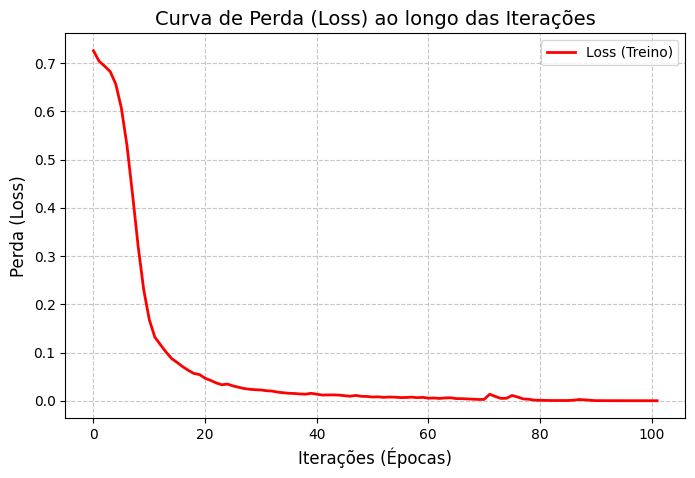

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(neural.loss_curve_, label='Loss (Treino)', color='red', linewidth=2)
plt.title('Curva de Perda (Loss) ao longo das Iterações', fontsize=14)
plt.xlabel('Iterações (Épocas)', fontsize=12)
plt.ylabel('Perda (Loss)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análise Gráfica

* **Curva de Perda:** O gráfico mostra uma descida suave e contínua do erro, indicando que o otimizador `adam` foi muito bom e não houve muita oscilação.

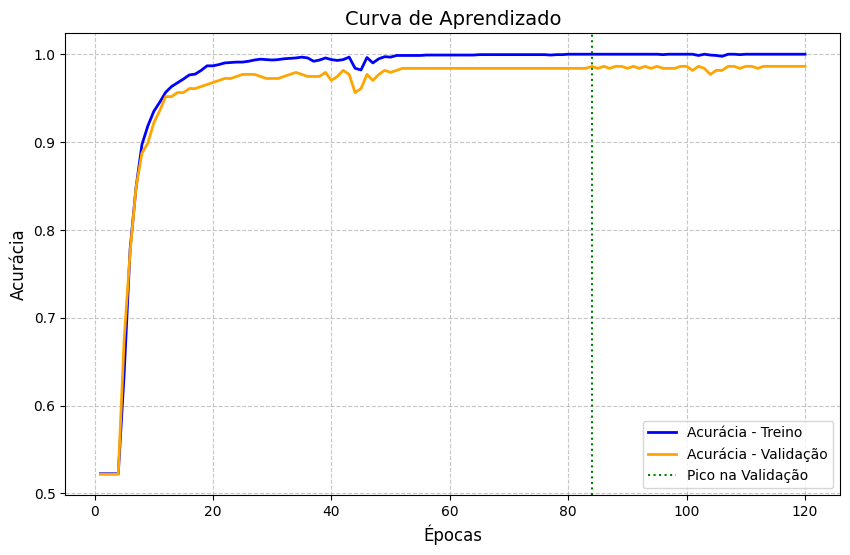

In [28]:
# instanciando o modelo baseline para treinar passo a passo
neural_step = MLPClassifier(
    hidden_layer_sizes=((16,)*8),
    activation="relu",
    solver="adam",
    random_state=69,
    warm_start=True, # permite continuar o treino de onde parou
    max_iter=1       # Treinamos apenas 1 época por vez para usar o partial_fit()
)

train_accs = []
val_accs = []

epochs = 120 # O modelo original convergiu em 102 épocas, então 120 é suficiente para observar
classes = [0, 1] # Classes possíveis do nosso target (vitória ou derrota)

# Fazemos um loop para o treinamento manual que nos permite avaliar cada instância e plotar o gráfico
for epoch in range(epochs):
    neural_step.partial_fit(X_train_concated, Y_train_encoded, classes=classes)
    
    train_acc = accuracy_score(Y_train_encoded, neural_step.predict(X_train_concated))
    val_acc = accuracy_score(Y_val_encoded, neural_step.predict(X_val_concated))
    
    train_accs.append(train_acc)
    val_accs.append(val_acc)

# Gráfico 
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_accs, label='Acurácia - Treino', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_accs, label='Acurácia - Validação', color='orange', linewidth=2)

plt.title('Curva de Aprendizado', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.axvline(x=val_accs.index(max(val_accs))+1, color='green', linestyle=':', label='Pico na Validação')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

* **Curva de Aprendizado (Treino X Validação):** Observando, notamos que a linha do Treino chega a 100% (1.0) rapidamente e se estabiliza. A linha de Validação acompanha o crescimento inicial, mas atinge um limite um pouco abaixo dos 100% (em torno de 98.6% como vimos antes) e não o ultrapassa. 
* **Conclusão:** Apesar da acurácia de treino atingir 100% (indicando que o modelo memorizou perfeitamente os exemplos de treino), não há grande distância entre as duas curvas (como vimos ser sinal de overfitting durante as aulas) e a acurácia de validação não começa a cair conforme as épocas avançam. Portanto, há um leve sobreajuste natural (provavelmente por serem dados discretos mais fáceis de aprender), mas o modelo não está sofrendo de *overfitting severo*, mantendo a capacidade de generalização.

# Busca de hiperparâmetros

Cumprindo os requisitos da Etapa 3 do projeto, vamos aplicar o **Grid Search com Cross-Validation** para encontrar a combinação ideal de hiperparâmetros.

Parâmetros investigados:
1. **`hidden_layer_sizes` (Arquitetura da Rede):** Vamos testar redes com mais e com menos camadas intermediárias, mudando os neurônios quanto mais profunda a camada: 4 camadas ocultas e um número de neurônios progressivamente maior: 8, 16, 32 e 64.
2. **`activation` (Função de Ativação):** Vamos comparar a `relu` com a `tanh` e a `logistic` (sigmóide).

Isso nos dará 12 combinações diferentes (4 arquiteturas × 3 ativações), atingindo o requisito mínimo exigido.

In [29]:
# Dicionário contendo as combinações dos hiperparâmetros
param_grid = {
    'hidden_layer_sizes': [(8,)*4, (16,)*4, (32,)*4, (64,)*4],
    'activation': ["relu", "tanh", "logistic"]
}

In [30]:
# O cross-validation padrão do scikit-learn é 5 (5-fold)
grid = GridSearchCV(
    param_grid=param_grid, 
    estimator=MLPClassifier(random_state=69) # Mantemos a seed fixa para comparação justa
)

In [31]:
grid.fit(X_train_concated, Y_train_encoded)

c:\Users\Vinícius Abdon\OneDrive\Documentos\GitHub\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vinícius Abdon\OneDrive\Documentos\GitHub\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vinícius Abdon\OneDrive\Documentos\GitHub\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vinícius Abdon\OneDrive\Documentos\GitHub\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: Converg

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(random_state=69)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh', ...], 'hidden_layer_sizes': [(8, ...), (16, ...), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [32]:
print(grid.best_params_)
print(grid.best_score_)
print(accuracy_score(Y_test_encoded, grid.predict(X_test_concated)))
pd.DataFrame(grid.cv_results_)

{'activation': 'relu', 'hidden_layer_sizes': (64, 64, 64, 64)}
0.9896293007769146
0.9859375


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_hidden_layer_sizes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.648146,0.013538,0.002000,1.819495e-06,relu,"(8, 8, 8, 8)","{'activation': 'relu', 'hidden_layer_sizes': (...",0.964706,0.971698,0.983491,0.985849,0.985849,0.978319,0.008594,8
1,0.410092,0.028305,0.002000,1.907349e-07,relu,"(16, 16, 16, 16)","{'activation': 'relu', 'hidden_layer_sizes': (...",0.981176,0.983491,0.981132,0.990566,0.995283,0.986330,0.005652,5
2,0.397089,0.017463,0.002201,4.000189e-04,relu,"(32, 32, 32, 32)","{'activation': 'relu', 'hidden_layer_sizes': (...",0.978824,0.995283,0.983491,0.985849,0.988208,0.986331,0.005447,4
3,0.505314,0.034882,0.002800,7.484561e-04,relu,"(64, 64, 64, 64)","{'activation': 'relu', 'hidden_layer_sizes': (...",0.985882,0.988208,0.988208,0.992925,0.992925,0.989629,0.002821,1
4,0.735661,0.004813,0.002201,3.998521e-04,tanh,"(8, 8, 8, 8)","{'activation': 'tanh', 'hidden_layer_sizes': (...",0.976471,0.976415,0.978774,0.985849,0.981132,0.979728,0.003520,7
5,0.770426,0.047806,0.002400,4.893372e-04,tanh,"(16, 16, 16, 16)","{'activation': 'tanh', 'hidden_layer_sizes': (...",0.988235,0.988208,0.983491,0.992925,0.985849,0.987741,0.003130,2
6,0.980305,0.064072,0.002994,1.248148e-05,tanh,"(32, 32, 32, 32)","{'activation': 'tanh', 'hidden_layer_sizes': (...",0.985882,0.981132,0.983491,0.990566,0.992925,0.986799,0.004373,3
7,1.465929,0.107202,0.003601,4.898625e-04,tanh,"(64, 64, 64, 64)","{'activation': 'tanh', 'hidden_layer_sizes': (...",0.985882,0.983491,0.981132,0.992925,0.988208,0.986327,0.004057,6
8,0.074617,0.001357,0.002600,4.891252e-04,logistic,"(8, 8, 8, 8)","{'activation': 'logistic', 'hidden_layer_sizes...",0.522353,0.523585,0.523585,0.521226,0.521226,0.522395,0.001055,12
9,1.197869,0.548944,0.003401,4.897652e-04,logistic,"(16, 16, 16, 16)","{'activation': 'logistic', 'hidden_layer_sizes...",0.522353,0.959906,0.981132,0.983491,0.985849,0.886546,0.182332,11


In [33]:
pd.DataFrame(grid.cv_results_)[['param_activation', 'param_hidden_layer_sizes', 'mean_test_score', 'rank_test_score']].sort_values("rank_test_score")

,param_activation,param_hidden_layer_sizes,mean_test_score,rank_test_score
3,relu,"(64, 64, 64, 64)",0.989629,1
5,tanh,"(16, 16, 16, 16)",0.987741,2
6,tanh,"(32, 32, 32, 32)",0.986799,3
2,relu,"(32, 32, 32, 32)",0.986331,4
1,relu,"(16, 16, 16, 16)",0.986330,5
7,tanh,"(64, 64, 64, 64)",0.986327,6
4,tanh,"(8, 8, 8, 8)",0.979728,7
0,relu,"(8, 8, 8, 8)",0.978319,8
10,logistic,"(32, 32, 32, 32)",0.972190,9
11,logistic,"(64, 64, 64, 64)",0.969361,10


### Resultados do Grid Search 

Melhor configuração encontrada:
* **Arquitetura:** 4 camadas ocultas com 64 neurônios cada `(64, 64, 64, 64)`
* **Ativação:** `relu`
* **Score médio na Validação Cruzada:** ~98.96%
* **Acurácia final no Conjunto de Teste:** ~98.59%

Conclusões:
1. **Impacto da Ativação:** Fica evidente observando a tabela final que as funções `relu` e `tanh` foram melhores, entregando resultados superiores a 97%. A função `logistic` teve o pior desempenho geral, inclusive falhando criticamente na arquitetura menor (8 neurônios), entregando apenas ~52% de acurácia (praticamente um chute aleatório).

2. **Impacto da Arquitetura:** A rede não precisou ser excessivamente grande para aprender o problema. A configuração `(16, 16, 16, 16)` já é muito boa, mas com 64 neurônios ela melhora **levemente**. Considerando que o volume de dados não é muito grande, pode ser que a de `(64, 64, 64, 64)` esteja já entrando em overfitting, já que é muito pequena a melhora em relação à `(16, 16, 16, 16)`.

3. **Convergência:** Os avisos de `ConvergenceWarning` durante o treino do Grid Search ocorreram principalmente nas combinações mais complexas ou naquelas usando a função `logistic`, a qual sofre com o gradiente desvanescente.

### Análise de Sensibilidade de Hiperparâmetros (etapa individual) 

O procedimento consiste em: 1. Manter todos os hiperparâmetros fixos na melhor configuração encontrada. 2. Escolher um hiperparâmetro para investigar. 3. Realizar uma variação sistemática desse hiperparâmetro para observar seu impacto no desempenho do modelo.  Mínimo de 5 valores testados para o hiperparâmetro analisado.
Cada aluno deverá: executar os experimentos; registrar os resultados obtidos; comparar o desempenho entre as diferentes configurações; interpretar o impacto do hiperparâmetro analisado. 
📊 Recomenda-se produzir gráficos comparativos.

**Hiperparâmetro Escolhido: Solver.**

Tendo em vista que o `MLPClassifier` só tem três solvers, para cumprir as diretrizes de testar 5 configurações vou testar 3 solvers principais e criar as variações faltantes explorando como o `sgd` (descida de gradiente estocástica) lida com a taxa de aprendizado (`learning_rate`), que possui as opções `constant`, `invscaling` e `adaptive`.

In [ ]:
import time
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

config_base = {
    'hidden_layer_sizes': ((16,)*8),
    'activation': 'relu',
    'random_state': 69
}

# 5 Configuracoes para testar 
configuracoes_solver = [
    ({'solver': 'adam'}, 'Adam (Baseline)'),
    ({'solver': 'lbfgs'}, 'L-BFGS'),
    ({'solver': 'sgd', 'learning_rate': 'constant'}, 'SGD (Constant)'),
    ({'solver': 'sgd', 'learning_rate': 'invscaling'}, 'SGD (Invscaling)'),
    ({'solver': 'sgd', 'learning_rate': 'adaptive'}, 'SGD (Adaptive)')
]

resultados = []
modelos_treinados = {}

In [37]:
for config, nome in configuracoes_solver:
    print(f"Treinando modelo com: {nome}")
    
    params = config_base.copy() 
    params.update(config) 
    
    # Instanciamos o modelo passando o dicionário desempacotado (operador ** - muito feio credo python (ㆆ_ㆆ))
    modelo = MLPClassifier(**params)
    
    inicio = time.time()
    
    # Treinamos o modelo usando os dados já preparados anteriormente
    modelo.fit(X_train_concated, Y_train_encoded)
    
    tempo_treino = time.time() - inicio
    
    # Avalia no conjunto de validação
    previsoes = modelo.predict(X_val_concated)
    acuracia = accuracy_score(Y_val_encoded, previsoes)
    
    # Salva os resultados
    resultados.append({
        'Configuração': nome,
        'Acurácia Validação': acuracia,
        'Tempo (s)': tempo_treino,
        'Iterações': modelo.n_iter_
    })
    
    modelos_treinados[nome] = modelo
    print(f"Treino feito. Acurácia: {acuracia:.4f} | Tempo: {tempo_treino:.2f}s | Iterações: {modelo.n_iter_}\n")

Treinando modelo com: Adam (Baseline)
Treino feito. Acurácia: 0.9862 | Tempo: 0.79s | Iterações: 102

Treinando modelo com: L-BFGS
Treino feito. Acurácia: 0.9908 | Tempo: 0.67s | Iterações: 157

Treinando modelo com: SGD (Constant)


c:\Users\Vinícius Abdon\OneDrive\Documentos\GitHub\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Treino feito. Acurácia: 0.9701 | Tempo: 1.39s | Iterações: 200

Treinando modelo com: SGD (Invscaling)
Treino feito. Acurácia: 0.5218 | Tempo: 0.15s | Iterações: 21

Treinando modelo com: SGD (Adaptive)
Treino feito. Acurácia: 0.9701 | Tempo: 1.36s | Iterações: 200



c:\Users\Vinícius Abdon\OneDrive\Documentos\GitHub\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### Resultados Estatísticos:

<div style="background: linear-gradient(to right, red, orange, yellow, green, blue, indigo, violet); -webkit-background-clip: text; background-clip: text; color: transparent; font-size: 20px; font-weight: bold;">
    1. O solver L-BFGS foi claramente o melhor, quase gabaritando o conjunto de validação!
</div>

<div style="font-size: 12px; font-weight: bold;">
    Passei muito mais tempo fazendo esse texto ser arco íris do que eu gostaria de adimitir.
</div>

---

<center>
 <img src='https://static.wikia.nocookie.net/kirby/images/1/15/KRtDLDX_Medal_Platinum.png/revision/latest?cb=20240426134645&path-prefix=en' width='200px' />
</center>


*O que aconteceu?* - Teve a maior acurácia (`99,08%`) e foi bizarramente mais rápido do que todos (⊙_⊙)!？ (0,67 segundos), convergindo em 157 iterações.

*Por que?* -  O L-BFGS usa aproximações matemáticas mais complexas (derivadas de segunda ordem 💥). Para datasets de tamanho pequeno a médio (como este), ele acaba destruindo a competição pois a segunda derivada é muito mais rápida de ser calculada em conjuntos pequenos. Ele encontrou o o menor erro **muito** rápido.

Restante dos solvers:

<div style="background: linear-gradient(to right, gold, orange, yellow, orange, gold); -webkit-background-clip: text; background-clip: text; color: transparent; font-size: 18px;">
    2. Adam (usado na Baseline): Estável (é o padrão do scikit)
</div>
<div style="background: linear-gradient(to right, white, #BCC6CC, silver, #BCC6CC, white); -webkit-background-clip: text; background-clip: text; color: transparent; font-size: 18px;">
    3. SGD (Constant e Adaptive): Precisavam de mais tempo 
</div>

- o SGD gerou dois avisos de `convergence_warning` indicando que atingiram o máximo de iterações (200) e não chegaram ao seu melhor resultado. Quem sabe com mais fossem melhor.

<div style="background: linear-gradient(to right, orange, brown, orange); -webkit-background-clip: text; background-clip: text; color: transparent; font-size: 18px;">
    4. SGD (Invscaling): Muito burro da zero pra ele 
</div>

- brincadeiras a parte, é interessante que ele obteve uma acurácia de 52,18%, praticamente um chute aleatório, terminando em míseras 21 iterações (0,15s).
- *O que gerou isso?* Pelo que eu entendi, a estratégia `invscaling` reduz a taxa de aprendizado progressivamente a cada passo. Não consigo pensar em um cenário que isso seja útil, porque aqui claramente atrapalhou e encerrou o aprendizdo muito precocemente, mas fica aí o questionamento.

Em suma, a variação do solver revelou que, para este dataset e com o limite de 200 iterações, métodos baseados no Gradiente Estocástico clássico (SGD) são lentos ou ineficientes, necessitando de mais épocas para convergir.

### Gráficos para comprovar:

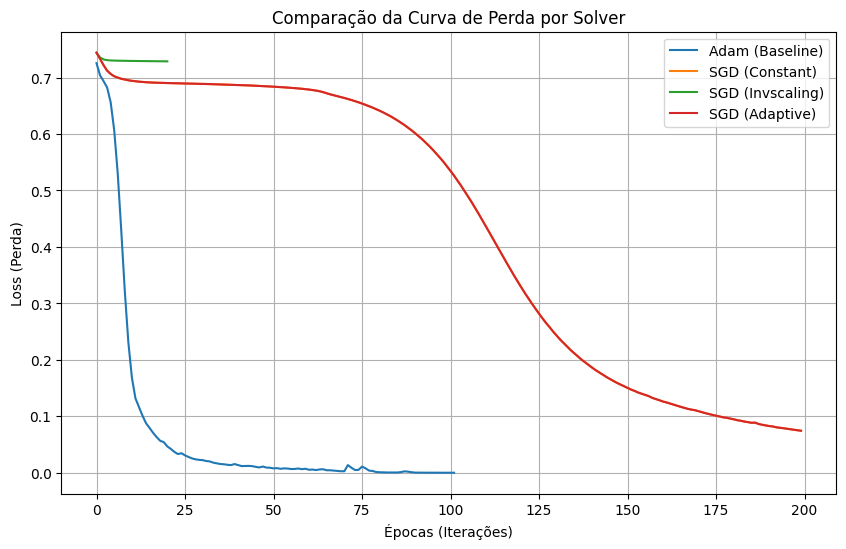

In [38]:
plt.figure(figsize=(10, 6))
for nome, modelo in modelos_treinados.items():
    # O L-BFGS infelizmente não suporta a extração da curva de perda no sklearn, então ignoramos ele neste plot
    if hasattr(modelo, 'loss_curve_'):
        plt.plot(modelo.loss_curve_, label=nome)

plt.title('Comparação da Curva de Perda por Solver')
plt.xlabel('Épocas (Iterações)')
plt.ylabel('Loss (Perda)')
plt.legend()
plt.grid(True)
plt.show()

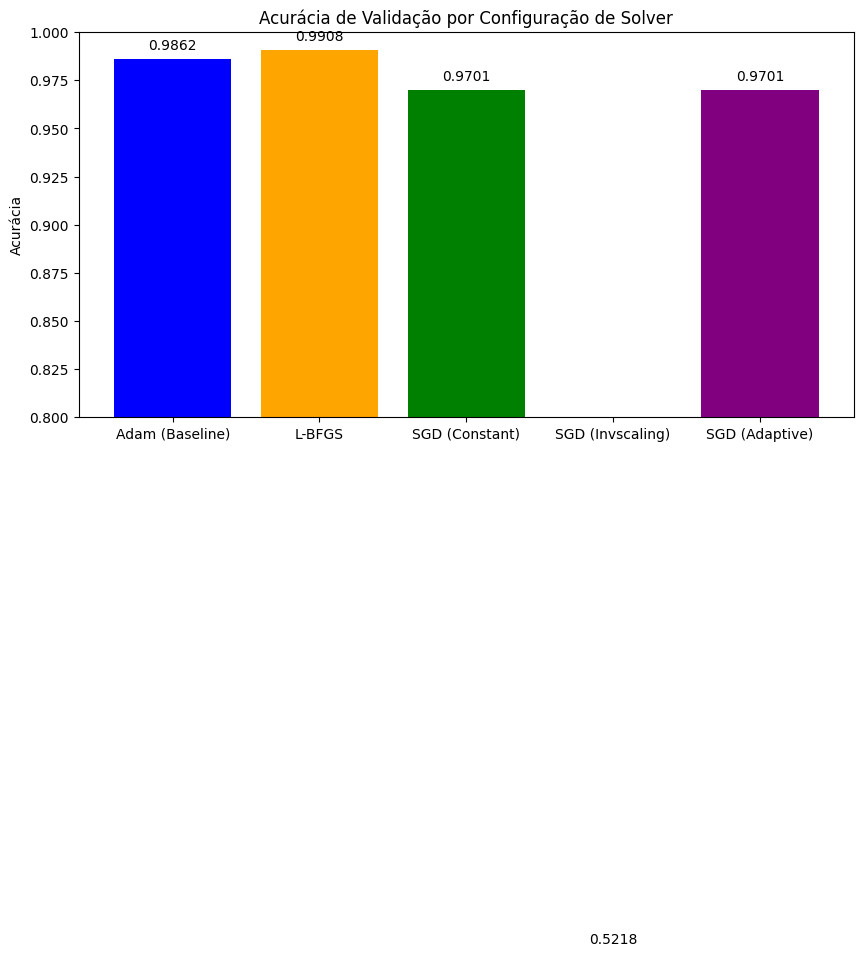

In [43]:
# Acurácias
nomes = [r['Configuração'] for r in resultados]
acuracias = [r['Acurácia Validação'] for r in resultados]

plt.figure(figsize=(10, 5))
plt.bar(nomes, acuracias, color=['blue', 'orange', 'green', 'red', 'purple'])
plt.title('Acurácia de Validação por Configuração de Solver')
plt.ylabel('Acurácia')
plt.ylim(0.8, 1.0) # Ajuste do eixo Y para destacar as diferenças
for i, v in enumerate(acuracias):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()